In [ ]:
%load_ext autoreload
%autoreload 2

# Enable packages in project notebook (not required for .py scripts)
import sys
import os

# Add the project root or parent folder to sys.path
sys.path.append(os.path.abspath("../../")) 


import yaml
import pickle
from tqdm import tqdm

import numpy as np
import jax.numpy as jnp
import pandas as pd

import seaborn as sns
from matplotlib import pyplot as plt
from flax import linen as nn

palette = sns.color_palette("Paired", 6)

import jax
import optax
import torch
import torch.utils.data as data

import counterfactual_alignment as cfa
from counterfactual_alignment import custom_datasets, custom_models, loss_functions, knowledge_functions
from counterfactual_alignment import utilities as ut

from counterfactual_alignment.pipeline import Pipeline




The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [91]:
"""
Gen Datasets
"""

"""
Initialise Parameters
"""

config_file = "config.yaml" #assuming local yaml file
with open(config_file,'r') as file:
    config = yaml.unsafe_load(file)

seed = seed=config['hyperparams']['seed']
key = jax.random.PRNGKey(seed)
noise_key,sample_key,model_key = jax.random.split(key,3)


size = config['data_params']['train_size'] + config['data_params']['validation_size']

moons = custom_datasets.TwoMoons(seed,size)
X = moons.X
Y = moons.Y
optimum_classifier = moons.optimum_classifier

X_dims = len(X[0])

X_train_CE,Y_train_CE,X_test,Y_test = ut.balanced_class_sample(X,Y,int(config['data_params']['train_size']/2))

In [90]:
optimum_classifier([[0,0],
                    [1,1]])

array([0, 1])

In [73]:

# sample_indices = np.empty(0)
# # sample training set
# for i,_ in enumerate(list(set(Y))):
#       sample_indices = np.concatenate((sample_indices,jax.random.randint(sample_key,tuple([int(config['data_params']['train_size']/2)]),np.ceil(i*size/2),np.floor((i+1)*size/2))))

# # sample_indices = jax.random.permutation(sample_key,size)[:config['data_params']['train_size']] 


# X_train_CE = np.array([X[int(i)] for i in sample_indices])
# Y_train_CE = np.array([Y[int(i)] for i in sample_indices])


# X_test = np.array([X[i] for i in range(size) if i not in sample_indices])
# Y_test = np.array([Y[i] for i in range(size) if i not in sample_indices])

full_df = pd.DataFrame({'x_0':X[:,0],
                         'x_1':X[:,1],
                         'Class':Y})

train_df = pd.DataFrame({'x_0':X_train_CE[:,0],
                         'x_1':X_train_CE[:,1],
                         'Class':Y_train_CE})

test_df = pd.DataFrame({'x_0':X_test[:,0],
                         'x_1':X_test[:,1],
                         'Class':Y_test})


datasets = {'train' :data.TensorDataset(torch.tensor(X_train_CE),torch.tensor(Y_train_CE),torch.tensor(np.zeros_like(X_train_CE))),
            'test'  :data.TensorDataset(torch.tensor(X_test),torch.tensor(Y_test),torch.tensor(np.zeros_like(X_test)))}


Add path of points between observation and counterfactual

In [88]:
n_samples = config['data_params']['n_vec']

# knowledge = knowledge_functions.counterfactual_vector_paths(X_train_CE,Y_train_CE,classifier=optimum_classifier,n_samples=n_samples)
knowledge = knowledge_functions.counterfactual_vector_paths(X_train_CE,Y_train_CE,classifier=optimum_classifier,n_samples=n_samples)

X_train_D = knowledge['origin'].reshape(int(n_samples*config['data_params']['train_size']),X_dims)
Y_train_D = np.array([[y]*n_samples for y in Y_train_CE]).reshape(int(n_samples*config['data_params']['train_size']))

K_df = pd.DataFrame({'x_0':X_train_D[:,0],
                      'x_1':X_train_D[:,1],
                      'Class':Y_train_D})

# 

k_dim = np.shape(knowledge['origin'])

K_train_D = np.vstack([
    knowledge['vector'][i] for i in range(k_dim[0]) for _ in range(k_dim[1])
])


batch = {'train':{
            'original':{
                'X':X_train_CE,
                'Y':Y_train_CE
            },
            'additional':{
                'X':X_train_D,
                'Y':Y_train_D,
                'K':K_train_D
            }},
         'test':{
             'X':X_test,
             'Y':Y_test
         }}



Generating 2 counterfactual samples per observation ...


10it [00:00, 1536.32it/s]


### Visualise

(23, 38)
(874,)
(874,)


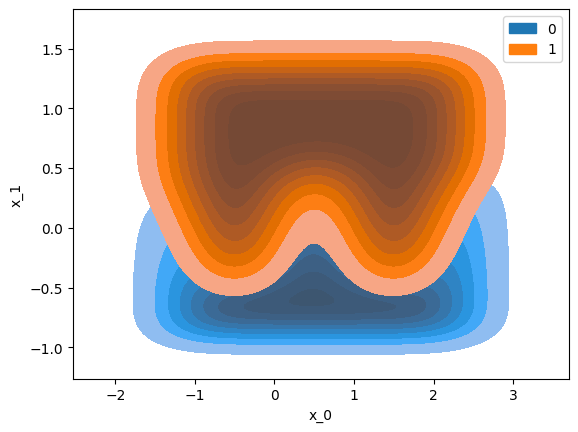

In [115]:

if config['visualisation']['visualise']:
#     fulldata_scatter = sns.scatterplot(data=full_df,x='x_0',y='x_1',hue='Class',palette=[palette[0],palette[2]],alpha=0.5,s=5,legend=False)
    test_scatter = sns.scatterplot(data=test_df,x='x_0',y='x_1',hue='Class',palette=[palette[0],palette[2]])
    K_scatter = sns.scatterplot(data=K_df,x='x_0',y='x_1',hue='Class',palette=[palette[4],palette[5]],legend=False)
    train_scatter = sns.scatterplot(data=train_df,x='x_0',y='x_1',hue='Class',palette=[palette[1],palette[3]],legend=False)
    h = 0.1

    x_min, x_max = X_train_CE[:, 0].min() - .5, X_train_CE[:, 0].max() + .5
    y_min, y_max = X_train_CE[:, 1].min() - .5, X_train_CE[:, 1].max() + .5
    lims = [[x_min, x_max], [y_min, y_max]]
    xx, yy = np.meshgrid(np.arange(lims[0][0], lims[0][1], h),
                        np.arange(lims[1][0], lims[1][1], h))
    print(np.shape(xx))
    print(np.shape(xx.ravel()))
    print(np.shape(yy.ravel()))
    Z = optimum_classifier(np.stack([xx.ravel(), yy.ravel()]).T)

    Z_r = Z.reshape(xx.shape)

    # sns.kdeplot (x=Z_r[:,0],y=Z_r[:,1],multiple='fill',hue=Y_train_CE)
    sns.kdeplot (x=xx.ravel(),y=yy.ravel(),fill=True,hue=Z)
    # plt.contourf(Z_r)
    

### Method 1
baseline

Loading and saving to: MODEL_simple__OPTIM_adam__LR_0.1__BATCHSIZE_8__DATA___SIZE_10__LOSS_combined_loss__ALPHA_0.0__METHOD_baseline


 15%|█▌        | 3/20 [00:00<00:00, 26.43it/s]

Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0


 30%|███       | 6/20 [00:00<00:00, 27.21it/s]

Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0


...

Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0


 90%|█████████ | 18/20 [00:00<00:00, 28.49it/s]

Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0


100%|██████████| 20/20 [00:00<00:00, 28.11it/s]


Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Model saved to /outputs as: MODEL_simple__OPTIM_adam__LR_0.1__BATCHSIZE_8__DATA___SIZE_10__LOSS_combined_loss__ALPHA_0.0__METHOD_baseline. Trained for 20 epochs.


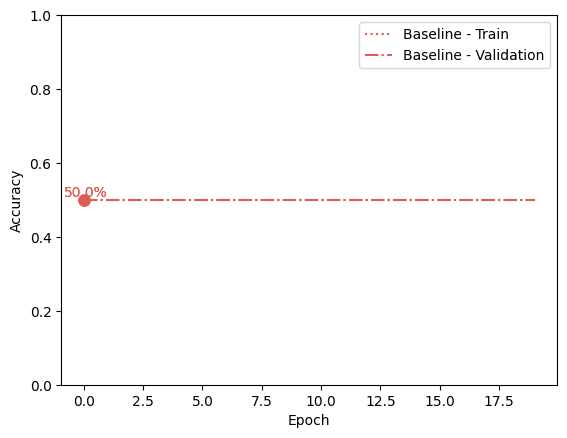

In [86]:
config['hyperparams']['loss_function'] = 'combined_loss'
config['hyperparams']['loss_mix'] = 0.0

pipeline = Pipeline(batch,data_description="",method_description="baseline",overwrite=True, config = config)

pipeline.run(n_epochs=config['hyperparams']['epochs'])
baseline_name = pipeline.output_name

res = []
for output_name in [pipeline.output_name]:
        with open(os.path.join('outputs',output_name+'.pkl'), 'rb') as file: ## remove this line to load model
                res.append(pickle.load(file))


res_fig=ut.plot_from_results_file([r['results'] for r in res],loss=True, labels=['Baseline',"With K"])



Loading and saving to: MODEL_simple__OPTIM_adam__LR_0.1__BATCHSIZE_8__DATA___SIZE_10__LOSS_combined_loss__ALPHA_0.5__METHOD_mixed


  0%|          | 0/20 [00:00<?, ?it/s]

Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0


 15%|█▌        | 3/20 [00:00<00:00, 25.63it/s]

Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0


...

Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0


 90%|█████████ | 18/20 [00:00<00:00, 28.22it/s]

Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0


100%|██████████| 20/20 [00:00<00:00, 27.69it/s]


Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Model saved to /outputs as: MODEL_simple__OPTIM_adam__LR_0.1__BATCHSIZE_8__DATA___SIZE_10__LOSS_combined_loss__ALPHA_0.5__METHOD_mixed. Trained for 20 epochs.


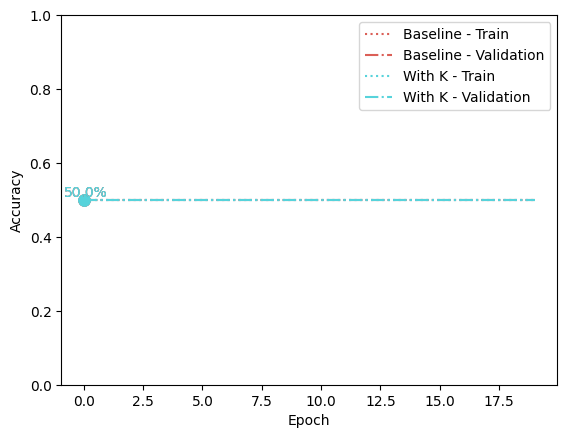

In [77]:

config['hyperparams']['loss_mix'] = 0.5

pipeline = Pipeline(batch,config = config,data_description="",method_description="mixed",overwrite=True)
pipeline.run(n_epochs=config['hyperparams']['epochs'])

res = []
for output_name in [baseline_name,pipeline.output_name]:
        with open(os.path.join('outputs',output_name+'.pkl'), 'rb') as file: ## remove this line to load model
                res.append(pickle.load(file))

res_fig=ut.plot_from_results_file([r['results'] for r in res],loss=True, labels=['Baseline',"With K"])

Loading and saving to: MODEL_simple__OPTIM_adam__LR_0.1__BATCHSIZE_8__DATA___SIZE_10__LOSS_combined_loss__ALPHA_1.0__METHOD_mixed


  0%|          | 0/20 [00:00<?, ?it/s]

Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0


 15%|█▌        | 3/20 [00:00<00:00, 25.55it/s]

Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0


...

Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0


 90%|█████████ | 18/20 [00:00<00:00, 28.41it/s]

Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0


100%|██████████| 20/20 [00:00<00:00, 27.89it/s]

Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Model saved to /outputs as: MODEL_simple__OPTIM_adam__LR_0.1__BATCHSIZE_8__DATA___SIZE_10__LOSS_combined_loss__ALPHA_1.0__METHOD_mixed. Trained for 20 epochs.


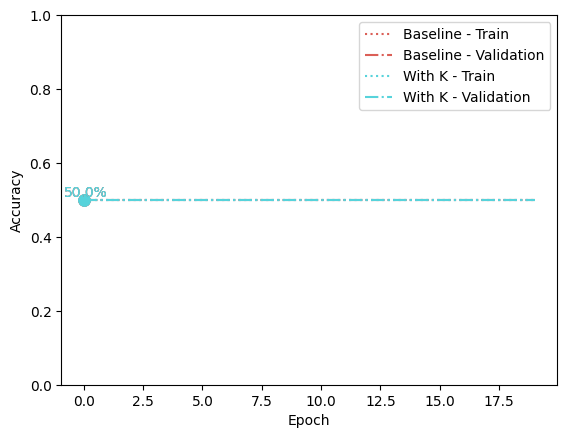

In [78]:
config['hyperparams']['loss_mix'] = 1.0

pipeline = Pipeline(batch,config = config,data_description="",method_description="mixed",overwrite=True)
pipeline.run(n_epochs=config['hyperparams']['epochs'])

res = []
for output_name in [baseline_name,pipeline.output_name]:
        with open(os.path.join('outputs',output_name+'.pkl'), 'rb') as file: ## remove this line to load model
                res.append(pickle.load(file))


res_fig=ut.plot_from_results_file([r['results'] for r in res],loss=True, labels=['Baseline',"With K"])

Loading and saving to: MODEL_simple__OPTIM_adam__LR_0.1__BATCHSIZE_8__DATA___SIZE_10__LOSS_combined_loss__ALPHA_0.0__METHOD_feasible_path


  0%|          | 0/20 [00:00<?, ?it/s]

Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0


 15%|█▌        | 3/20 [00:00<00:00, 25.93it/s]

Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0


...

Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0


 90%|█████████ | 18/20 [00:00<00:00, 24.56it/s]

Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0


100%|██████████| 20/20 [00:00<00:00, 26.38it/s]

Train Loss: nan, Train Accuracy: 50.0
Validation Loss: nan, Validation Accuracy: 50.0
Model saved to /outputs as: MODEL_simple__OPTIM_adam__LR_0.1__BATCHSIZE_8__DATA___SIZE_10__LOSS_combined_loss__ALPHA_1.0__METHOD_feasible_path. Trained for 20 epochs.


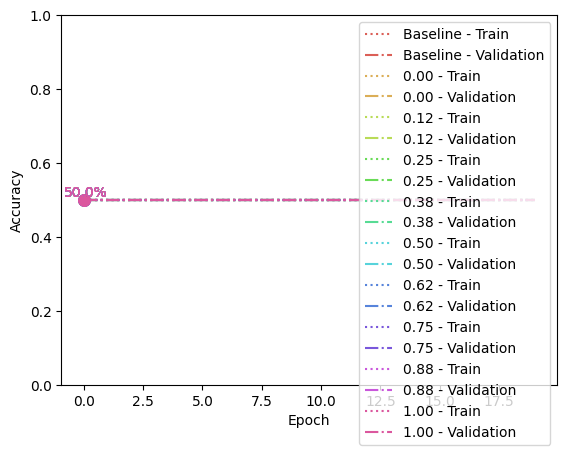

In [79]:
output_names = [baseline_name]

for mix_rate in np.linspace(0,1,9):
    config['hyperparams']['loss_mix'] = mix_rate

    pipeline = Pipeline(batch,config = config,data_description="",method_description="feasible_path",overwrite=True)
    pipeline.run(n_epochs=config['hyperparams']['epochs'])
    output_names.append(pipeline.output_name)


res = []
for output_name in output_names:
        with open(os.path.join('outputs',output_name+'.pkl'), 'rb') as file: ## remove this line to load model
                res.append(pickle.load(file))

res_fig=ut.plot_from_results_file([r['results'] for r in res],loss=True, labels=['Baseline']+[f"{n:.2f}"for n in np.linspace(0,1,9)])

In [80]:
import jax
import jax.numpy as jnp
from jax import random, grad
import numpy as np
from flax import traverse_util

def test_direction_loss_differentiable(batch,direction_loss_fn, model):
    # Fake input data
    rng = random.PRNGKey(0)
    
    
    # Initialize model params
    if isinstance(batch,dict):
        try:
            init_X = batch['original']['X']
        
        except:
            try:
                init_X = batch['X']
        
            except:
                raise ValueError("cannot recognise batch")
    else:
        raise ValueError("cannot recognise batch - should be dict")
    
    variables = model.init(rng, np.ones_like(init_X))
    params = variables["params"]

    # Wrap in batch
    

    try:
        # Try computing gradients
        loss_grad_fn = grad(direction_loss_fn)
        
        grads = loss_grad_fn(params, model, batch, rng, config)
        for path, grad_i in traverse_util.flatten_dict(grads).items():
            norm = jnp.linalg.norm(grad_i)
            print(".".join(path), norm, grad_i)

        flat_grads, _ = jax.flatten_util.ravel_pytree(grads)
        if jnp.isnan(flat_grads).any():
            print("❌ Gradient contains NaNs.")
        else:
            print("✅ Gradient computed successfully. Loss is differentiable.")
    except Exception as e:
        print("❌ Gradient computation failed:")
        print(e)

In [81]:
test_pipeline = Pipeline(batch,config = config,data_description="",method_description="mixed",overwrite=True)

In [82]:
for key,val in batch['train']['additional'].items():
    print(key,val)

test_direction_loss_differentiable(batch['train'],loss_functions.direction_wrapper,pipeline.model)

X [[ 1.13875090e-01  1.29675361e-02]
 [ 1.15976187e-01  1.34504758e-02]
 [ 2.21114783e-02  4.88917470e-04]
 [ 2.98408526e-01  8.90476485e-02]
 [ 0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00]
 [-8.48367974e-02  7.19728220e-03]
 [-5.95496694e-02  3.54616312e-03]
 [ 0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00]
 [ 1.77343014e+00  3.14505446e+00]
 [ 1.90637267e+00  3.63425674e+00]
 [ 0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00]
 [ 2.00000000e+00  4.00000000e+00]
 [ 2.00000000e+00  4.00000000e+00]
 [ 5.00687918e-01  2.50688391e-01]
 [ 5.13070444e-01  2.63241281e-01]
 [ 8.66025404e-01  7.50000000e-01]
 [ 8.66025404e-01  7.50000000e-01]]
Y [0 0 1 1 1 1 0 0 1 1 1 1 0 0 1 1 0 0 0 0]
K [[-1.  0.]
 [-1.  0.]
 [ 1.  0.]
 [ 1.  0.]
 [nan nan]
 [nan nan]
 [-1.  0.]
 [-1.  0.]
 [nan nan]
 [nan nan]
 [ 1.  0.]
 [ 1.  0.]
 [nan nan]
 [nan nan]
 [ 0. -1.]
 [ 0. -1.]
 [ 1.  0.]
 [ 1.  0.]
 [ 0.  1.]
 [ 0.  1.]]
linear1.bias nan [nan nan nan 